In [1]:
# --- 0. Import Libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import logging
import json
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ============================================================
# 0.1 Setup Logging
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('../logs/feature_selection.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


In [4]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'raw'
MODEL_DIR = BASE_DIR / 'models'
LOG_DIR = BASE_DIR / 'logs'

# Create directories if not exist
for directory in [PROCESSED_DIR, MODEL_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [8]:
# ============================================================
# 1. Custom Transformers
# ============================================================

class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Clip outliers using IQR method.
    Learns bounds from training data to prevent data leakage.
    """
    def __init__(self, factor=1.5):
        self.factor = factor
        self.bounds_ = {}
    
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        for col in X_df.columns:
            q1, q3 = X_df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - self.factor * iqr
            upper = q3 + self.factor * iqr
            self.bounds_[col] = (lower, upper)
            
        logger.info(f"Outlier bounds calculated for {len(self.bounds_)} features")
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        for col, (lower, upper) in self.bounds_.items():
            if col in X_df.columns:
                X_df[col] = np.clip(X_df[col], lower, upper)
        
        return X_df


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Create advanced features from existing ones.
    """
    def __init__(self):
        self.feature_names_ = None
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Total nights
        if 'stays_in_weekend_nights' in X_df.columns and 'stays_in_week_nights' in X_df.columns:
            X_df['total_nights'] = X_df['stays_in_weekend_nights'] + X_df['stays_in_week_nights']
        
        # Total guests
        if all(col in X_df.columns for col in ['adults', 'children', 'babies']):
            X_df['total_guests'] = X_df['adults'] + X_df['children'] + X_df['babies']
            X_df['total_guests'] = X_df['total_guests'].replace(0, 1)  # Avoid division by zero
        
        # Weekend ratio
        if 'stays_in_weekend_nights' in X_df.columns and 'total_nights' in X_df.columns:
            X_df['weekend_ratio'] = X_df['stays_in_weekend_nights'] / (X_df['total_nights'] + 1)
        
        # Is family
        if 'children' in X_df.columns and 'babies' in X_df.columns:
            X_df['is_family'] = ((X_df['children'] + X_df['babies']) > 0).astype(int)
        
        # Lead time categories
        if 'lead_time' in X_df.columns:
            X_df['lead_time_category'] = pd.cut(
                X_df['lead_time'], 
                bins=[0, 7, 30, 90, 365, 9999],
                labels=['very_short', 'short', 'medium', 'long', 'very_long']
            ).astype(str)
        
        # Booking changes indicator
        if 'booking_changes' in X_df.columns:
            X_df['has_changes'] = (X_df['booking_changes'] > 0).astype(int)
        
        # Special requests indicator
        if 'total_of_special_requests' in X_df.columns:
            X_df['has_special_requests'] = (X_df['total_of_special_requests'] > 0).astype(int)
        
        self.feature_names_ = X_df.columns.tolist()
        logger.info(f"Engineered {len(self.feature_names_)} features")
        
        return X_df


class HighCorrelationRemover(BaseEstimator, TransformerMixin):
    """
    Remove highly correlated features.
    """
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.columns_to_drop_ = []
    
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        # Calculate correlation matrix
        corr_matrix = X_df.corr().abs()
        
        # Select upper triangle
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        
        # Find features with correlation greater than threshold
        self.columns_to_drop_ = [
            column for column in upper.columns 
            if any(upper[column] > self.threshold)
        ]
        
        if self.columns_to_drop_:
            logger.warning(f"Removing {len(self.columns_to_drop_)} highly correlated features: {self.columns_to_drop_}")
        else:
            logger.info("No highly correlated features found")
        
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        return X_df.drop(columns=self.columns_to_drop_, errors='ignore')


In [32]:
# ============================================================
# 2. Load and Validate Data
# ============================================================

def load_data():
    """Load data with proper validation."""
    try:
        #df = pd.read_csv(PROCESSED_DIR / 'hotel_bookings_clean.csv')
        df = pd.read_csv(PROCESSED_DIR / 'hotel_bookings_featured.csv')        
        logger.info(f" Loaded processed data: {df.shape}")
    except FileNotFoundError:
        logger.warning(" Processed data not found, loading raw data")
        df = pd.read_csv(RAW_DIR / 'hotel_bookings.csv')
        logger.info(f"Loaded raw data: {df.shape}")
    
    return df


def validate_target(df, target_col='adr'):
    """Validate target variable."""
    logger.info(f"\n--- Target Validation: {target_col} ---")
    
    # Check missing values
    missing = df[target_col].isnull().sum()
    logger.info(f"Missing values: {missing} ({missing/len(df)*100:.2f}%)")
    
    # Check negative/zero values
    invalid = (df[target_col] <= 0).sum()
    logger.info(f"Zero/negative values: {invalid} ({invalid/len(df)*100:.2f}%)")
    
    # Distribution stats
    logger.info(f"Mean: {df[target_col].mean():.2f}")
    logger.info(f"Median: {df[target_col].median():.2f}")
    logger.info(f"Std: {df[target_col].std():.2f}")
    logger.info(f"Skewness: {df[target_col].skew():.2f}")
    
    # Remove invalid rows
    df_clean = df[
        (df[target_col].notnull()) & 
        (df[target_col] > 0)
    ].copy()
    
    removed = len(df) - len(df_clean)
    if removed > 0:
        logger.warning(f" Removed {removed} rows with invalid target values")
    
    return df_clean


# ============================================================
# 3. Load Data
# ============================================================

df = load_data()
df = validate_target(df)

logger.info(f"Final data shape: {df.shape}")

2025-11-10 14:04:44,754 - INFO -  Loaded processed data: (113370, 70)
2025-11-10 14:04:44,755 - INFO - 
--- Target Validation: adr ---
2025-11-10 14:04:44,757 - INFO - Missing values: 0 (0.00%)
2025-11-10 14:04:44,758 - INFO - Zero/negative values: 0 (0.00%)
2025-11-10 14:04:44,758 - INFO - Mean: 98.76
2025-11-10 14:04:44,761 - INFO - Median: 93.60
2025-11-10 14:04:44,762 - INFO - Std: 38.88
2025-11-10 14:04:44,763 - INFO - Skewness: 0.56
2025-11-10 14:04:44,810 - INFO - Final data shape: (113370, 70)


In [33]:
# ============================================================
# 4. Feature Configuration
# ============================================================

TARGET = 'adr'

DROP_COLS = [
    TARGET, 
    'is_canceled',  # Leakage
    'reservation_status',  # Leakage
    'reservation_status_date',  # Leakage
    'agent',  # Too many categories
    'company',  # Too many categories
    'country'  # Too many categories (can use region instead)
]

NUMERIC_FEATURES = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests'
]

CATEGORICAL_FEATURES = [
    'hotel', 'arrival_date_month', 'meal', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'assigned_room_type',
    'deposit_type', 'customer_type'
]

# Filter existing features
existing_features = [col for col in NUMERIC_FEATURES + CATEGORICAL_FEATURES if col in df.columns]
existing_numeric = [col for col in NUMERIC_FEATURES if col in df.columns]
existing_categorical = [col for col in CATEGORICAL_FEATURES if col in df.columns]

logger.info(f"\n--- Feature Configuration ---")
logger.info(f"Numeric features: {len(existing_numeric)}")
logger.info(f"Categorical features: {len(existing_categorical)}")
logger.info(f"Total features: {len(existing_features)}")

2025-11-10 14:04:46,102 - INFO - 
--- Feature Configuration ---
2025-11-10 14:04:46,104 - INFO - Numeric features: 16
2025-11-10 14:04:46,105 - INFO - Categorical features: 9
2025-11-10 14:04:46,105 - INFO - Total features: 25


In [34]:
# ============================================================
# 5. Feature Analysis
# ============================================================

def analyze_categorical_features(df, cat_features):
    """Analyze categorical features for high cardinality."""
    logger.info("\n--- Categorical Feature Analysis ---")
    
    high_cardinality = []
    for col in cat_features:
        n_unique = df[col].nunique()
        logger.info(f"{col}: {n_unique} unique values")
        
        if n_unique > 20:
            high_cardinality.append(col)
            logger.warning(f" {col} has high cardinality!")
    
    return high_cardinality


high_card_features = analyze_categorical_features(df, existing_categorical)

# ============================================================
# 6. Train/Validation/Test Split
# ============================================================

# First split: Train+Val (80%) vs Test (20%)
X = df[existing_features]
y = df[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Train (75% of 80% = 60%) vs Val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

logger.info(f"\n--- Data Split ---")
logger.info(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
logger.info(f"Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
logger.info(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")


2025-11-10 14:04:47,036 - INFO - 
--- Categorical Feature Analysis ---
2025-11-10 14:04:47,047 - INFO - hotel: 2 unique values
2025-11-10 14:04:47,053 - INFO - arrival_date_month: 12 unique values
2025-11-10 14:04:47,056 - INFO - meal: 5 unique values
2025-11-10 14:04:47,061 - INFO - market_segment: 8 unique values
2025-11-10 14:04:47,066 - INFO - distribution_channel: 5 unique values
2025-11-10 14:04:47,069 - INFO - reserved_room_type: 9 unique values
2025-11-10 14:04:47,072 - INFO - assigned_room_type: 11 unique values
2025-11-10 14:04:47,077 - INFO - deposit_type: 3 unique values
2025-11-10 14:04:47,082 - INFO - customer_type: 4 unique values
2025-11-10 14:04:47,133 - INFO - 
--- Data Split ---
2025-11-10 14:04:47,134 - INFO - Train: 68022 samples (60.0%)
2025-11-10 14:04:47,134 - INFO - Validation: 22674 samples (20.0%)
2025-11-10 14:04:47,135 - INFO - Test: 22674 samples (20.0%)


In [35]:
# ============================================================
# 7. Build Advanced Pipeline
# ============================================================

# Numeric pipeline (with outlier handling INSIDE pipeline)
numeric_transformer = Pipeline([
    ('outlier_clipper', OutlierClipper(factor=1.5)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline (with max_categories to prevent explosion)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore', 
        sparse_output=False,
        max_categories=15  # Limit categories per feature
    ))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, existing_numeric),
    ('cat', categorical_transformer, existing_categorical)
], remainder='drop')

# Full pipeline with feature engineering and selection
full_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('correlation_remover', HighCorrelationRemover(threshold=0.9)),
    ('feature_selector', SelectFromModel(
        LassoCV(
            cv=5, 
            random_state=42, 
            max_iter=5000,
            n_jobs=-1
        ),
        threshold='median'  # Can tune this
    ))
])

logger.info("\n🚀 Fitting pipeline on training data...")
logger.info("This may take a few minutes...")

# ============================================================
# 8. Fit Pipeline
# ============================================================

full_pipeline.fit(X_train, y_train)
logger.info(" Pipeline fitting complete!")

2025-11-10 14:04:47,965 - INFO - 
🚀 Fitting pipeline on training data...
2025-11-10 14:04:47,966 - INFO - This may take a few minutes...
2025-11-10 14:04:47,983 - INFO - Engineered 32 features
2025-11-10 14:04:48,001 - INFO - Outlier bounds calculated for 16 features
2025-11-10 14:04:49,930 - WARNING - Removing 4 highly correlated features: [17, 44, 67, 69]
2025-11-10 14:04:51,096 - INFO -  Pipeline fitting complete!


2025-11-10 14:04:51,113 - INFO - 
Features after engineering:
2025-11-10 14:04:51,114 - INFO -   Numeric: 22
2025-11-10 14:04:51,114 - INFO -   Categorical: 10
2025-11-10 14:04:51,115 - ERROR - Error extracting OHE feature names: input_features should have length equal to number of features (9), got 10
2025-11-10 14:04:51,117 - INFO - Engineered 32 features
2025-11-10 14:04:51,127 - WARNING - Using generic feature names: 75 features
2025-11-10 14:04:51,127 - WARNING - Could not track correlation removal: startswith first arg must be str or a tuple of str, not int
2025-11-10 14:04:51,128 - INFO -   Selector mask length: 71
2025-11-10 14:04:51,128 - INFO -   Features after correlation: 75
2025-11-10 14:04:51,128 - ERROR - Dimension mismatch! Mask: 71, Features: 75
2025-11-10 14:04:51,130 - INFO - Engineered 32 features
2025-11-10 14:04:51,140 - INFO -   Actual features before selector: 71
2025-11-10 14:04:51,140 - INFO -   Adjusted to 71 generic feature names
2025-11-10 14:04:51,141 - IN

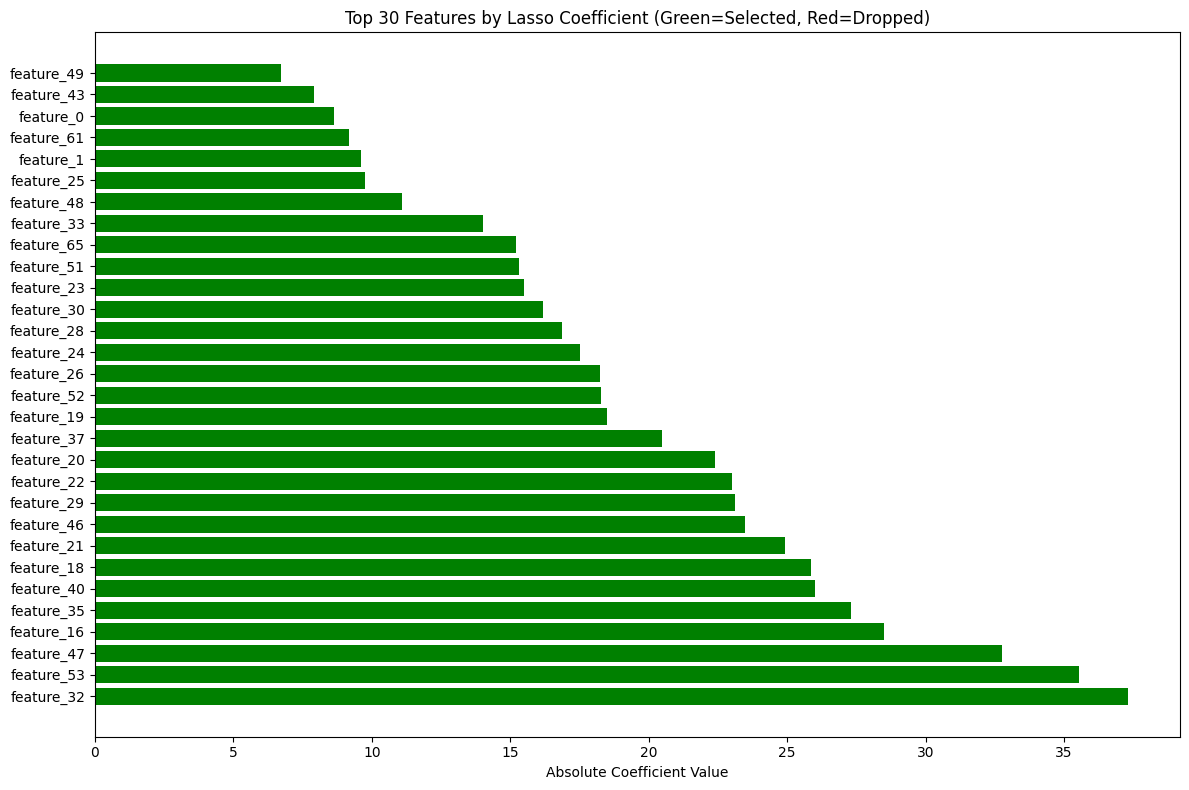

2025-11-10 14:04:51,553 - INFO - Saved: feature_importance.png


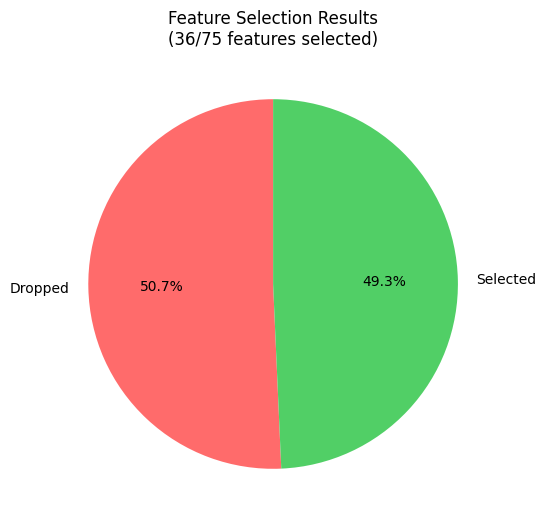

2025-11-10 14:04:51,647 - INFO - Saved: feature_selection_summary.png
2025-11-10 14:04:51,648 - INFO - 
--- Validation Set Performance ---
2025-11-10 14:04:51,652 - INFO - Engineered 32 features
2025-11-10 14:04:51,708 - INFO - Engineered 32 features
2025-11-10 14:04:51,869 - INFO - MAE: 19.28
2025-11-10 14:04:51,870 - INFO - RMSE: 25.60
2025-11-10 14:04:51,870 - INFO - R²: 0.5700
2025-11-10 14:04:51,876 - INFO - 
 All files saved:
2025-11-10 14:04:51,876 - INFO - - selected_features_list.csv
2025-11-10 14:04:51,876 - INFO - - feature_importance_full.csv
2025-11-10 14:04:51,876 - INFO - - feature_selection_pipeline.pkl
2025-11-10 14:04:51,877 - INFO - - pipeline_metadata.json
2025-11-10 14:04:51,877 - INFO - - feature_importance.png
2025-11-10 14:04:51,877 - INFO - - feature_selection_summary.png



FEATURE SELECTION SUMMARY REPORT

 Data:
  • Total samples: 113,370
  • Train: 68,022 (60.0%)
  • Validation: 22,674 (20.0%)
  • Test: 22,674 (20.0%)

 Features:
  • Original: 25
  • After engineering: 32
  • After encoding: 75
  • Final selected: 36
  • Reduction: 52.0%

 Validation Performance:
  • MAE: 19.28
  • RMSE: 25.60
  • R²: 0.5700

 Top 5 Most Important Features:
  33. feature_32: -37.3198
  54. feature_53: 35.5536
  48. feature_47: -32.7562
  17. feature_16: 28.5006
  36. feature_35: -27.3051

 Ready for model training!


In [36]:
# ============================================================
# 9. Extract Feature Information
# ============================================================

# Get feature names after engineering
engineered_features = full_pipeline.named_steps['feature_engineer'].feature_names_

# Update numeric and categorical lists after feature engineering
updated_numeric = [f for f in engineered_features if f in existing_numeric or f in [
    'total_nights', 'total_guests', 'weekend_ratio', 'has_changes', 
    'has_special_requests', 'is_family'
]]

updated_categorical = [f for f in engineered_features if f in existing_categorical or f == 'lead_time_category']

logger.info(f"\nFeatures after engineering:")
logger.info(f"  Numeric: {len(updated_numeric)}")
logger.info(f"  Categorical: {len(updated_categorical)}")

# Get feature names after preprocessing (including OHE)
try:
    # Get OHE feature names
    cat_transformer = full_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    ohe_feature_names = cat_transformer.named_steps['onehot'].get_feature_names_out(updated_categorical)
    
    # All transformed features (numeric + OHE)
    all_transformed_features = np.concatenate([
        updated_numeric,
        ohe_feature_names
    ])
    logger.info(f"  After OHE: {len(all_transformed_features)} total features")
    
except Exception as e:
    logger.error(f"Error extracting OHE feature names: {e}")
    # Fallback: transform a sample to get shape
    sample_transformed = full_pipeline.named_steps['preprocessor'].transform(
        full_pipeline.named_steps['feature_engineer'].transform(X_train.head(1))
    )
    n_features_after_preprocessing = sample_transformed.shape[1]
    all_transformed_features = np.array([f"feature_{i}" for i in range(n_features_after_preprocessing)])
    logger.warning(f"Using generic feature names: {len(all_transformed_features)} features")

# Get features after correlation removal
try:
    corr_remover = full_pipeline.named_steps['correlation_remover']
    if hasattr(corr_remover, 'columns_to_drop_') and len(corr_remover.columns_to_drop_) > 0:
        # Remove dropped columns from feature names
        dropped_indices = [i for i, col in enumerate(all_transformed_features) 
                          if any(str(col).startswith(dropped) for dropped in corr_remover.columns_to_drop_)]
        mask = np.ones(len(all_transformed_features), dtype=bool)
        mask[dropped_indices] = False
        features_after_corr = all_transformed_features[mask]
        logger.info(f"  After correlation removal: {len(features_after_corr)} features")
    else:
        features_after_corr = all_transformed_features
        logger.info(f"  No features removed by correlation filter")
except Exception as e:
    logger.warning(f"Could not track correlation removal: {e}")
    features_after_corr = all_transformed_features

# Get selected features mask from Lasso
selected_mask = full_pipeline.named_steps['feature_selector'].get_support()
logger.info(f"  Selector mask length: {len(selected_mask)}")
logger.info(f"  Features after correlation: {len(features_after_corr)}")

# Ensure dimensions match
if len(selected_mask) != len(features_after_corr):
    logger.error(f"Dimension mismatch! Mask: {len(selected_mask)}, Features: {len(features_after_corr)}")
    # Transform sample to verify
    sample_before_selector = full_pipeline[:-1].transform(X_train.head(1))
    logger.info(f"  Actual features before selector: {sample_before_selector.shape[1]}")
    
    # Use actual transformed shape
    if sample_before_selector.shape[1] == len(selected_mask):
        features_after_corr = np.array([f"feature_{i}" for i in range(sample_before_selector.shape[1])])
        logger.info(f"  Adjusted to {len(features_after_corr)} generic feature names")

selected_features = features_after_corr[selected_mask]

logger.info(f"\n--- Feature Selection Results ---")
logger.info(f"Features after engineering: {len(engineered_features)}")
logger.info(f"Features after encoding: {len(all_transformed_features)}")
logger.info(f"Features selected by LassoCV: {len(selected_features)}")
logger.info(f"Reduction: {len(all_transformed_features) - len(selected_features)} features removed")


# ============================================================
# 10. Get Feature Importances
# ============================================================

lasso_model = full_pipeline.named_steps['feature_selector'].estimator_
lasso_coef = np.array(lasso_model.coef_)
selected_mask = full_pipeline.named_steps['feature_selector'].get_support()

# 🔹 ใช้ชื่อฟีเจอร์จริงจาก transformation แทน all_transformed_features
sample_before_selector = full_pipeline[:-1].transform(X_train.head(1))
n_features_real = sample_before_selector.shape[1]

if len(lasso_coef) != n_features_real:
    logger.warning(f"Adjusting feature name length: coef={len(lasso_coef)}, transformed={n_features_real}")
    feature_names = np.array([f"feature_{i}" for i in range(n_features_real)])
else:
    feature_names = all_transformed_features[:n_features_real] if len(all_transformed_features) >= n_features_real else np.array([f"feature_{i}" for i in range(n_features_real)])

# ทำให้ mask กับ feature_names ยาวเท่ากันเสมอ
min_len = min(len(feature_names), len(lasso_coef), len(selected_mask))
feature_names = feature_names[:min_len]
lasso_coef = lasso_coef[:min_len]
selected_mask = selected_mask[:min_len]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_coef,
    'abs_coefficient': np.abs(lasso_coef),
    'selected': selected_mask
}).sort_values('abs_coefficient', ascending=False)

logger.info(f"\n--- Top 20 Most Important Features ---")
for idx, row in feature_importance.head(20).iterrows():
    status = "good" if row['selected'] else "bad"
    logger.info(f"{status} {row['feature']}: {row['coefficient']:.4f}")
# ============================================================
# 11. Visualizations
# ============================================================

# Plot 1: Feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(30)
colors = ['green' if x else 'red' for x in top_features['selected']]
plt.barh(range(len(top_features)), top_features['abs_coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 30 Features by Lasso Coefficient (Green=Selected, Red=Dropped)')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
logger.info("Saved: feature_importance.png")

# Plot 2: Selected vs Dropped
plt.figure(figsize=(8, 6))
selection_counts = feature_importance['selected'].value_counts()
plt.pie(selection_counts, labels=['Dropped', 'Selected'], autopct='%1.1f%%', 
        colors=['#ff6b6b', '#51cf66'], startangle=90)
plt.title(f'Feature Selection Results\n({len(selected_features)}/{len(all_transformed_features)} features selected)')
plt.savefig(PROCESSED_DIR / 'feature_selection_summary.png', dpi=300, bbox_inches='tight')
plt.show()
logger.info("Saved: feature_selection_summary.png")

# ============================================================
# 12. Validate on Validation Set
# ============================================================

logger.info("\n--- Validation Set Performance ---")

# Transform validation set
X_val_transformed = full_pipeline.transform(X_val)
X_train_transformed = full_pipeline.transform(X_train)

# Simple linear regression for quick validation
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

y_val_pred = lr.predict(X_val_transformed)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

logger.info(f"MAE: {mae:.2f}")
logger.info(f"RMSE: {rmse:.2f}")
logger.info(f"R²: {r2:.4f}")

# ============================================================
# 13. Export Results
# ============================================================

# Save selected features list
pd.DataFrame({
    "feature": selected_features
}).to_csv(PROCESSED_DIR / "selected_features_list.csv", index=False)

# Save full feature importance
feature_importance.to_csv(PROCESSED_DIR / "feature_importance_full.csv", index=False)

# Save pipeline
joblib.dump(full_pipeline, MODEL_DIR / "feature_selection_pipeline.pkl")

# Save metadata
metadata = {
    'timestamp': datetime.now().isoformat(),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'n_features_original': len(existing_features),
    'n_features_engineered': len(engineered_features),
    'n_features_encoded': len(all_transformed_features),
    'n_features_selected': len(selected_features),
    'lasso_alpha': float(lasso_model.alpha_),
    'validation_mae': float(mae),
    'validation_rmse': float(rmse),
    'validation_r2': float(r2)
}

with open(PROCESSED_DIR / 'pipeline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

logger.info("\n All files saved:")
logger.info("- selected_features_list.csv")
logger.info("- feature_importance_full.csv")
logger.info("- feature_selection_pipeline.pkl")
logger.info("- pipeline_metadata.json")
logger.info("- feature_importance.png")
logger.info("- feature_selection_summary.png")

# ============================================================
# 14. Summary Report
# ============================================================

print("\n" + "="*60)
print("FEATURE SELECTION SUMMARY REPORT")
print("="*60)
print(f"\n Data:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Train: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  • Validation: {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)")
print(f"  • Test: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")

print(f"\n Features:")
print(f"  • Original: {len(existing_features)}")
print(f"  • After engineering: {len(engineered_features)}")
print(f"  • After encoding: {len(all_transformed_features)}")
print(f"  • Final selected: {len(selected_features)}")
print(f"  • Reduction: {(1 - len(selected_features)/len(all_transformed_features))*100:.1f}%")

print(f"\n Validation Performance:")
print(f"  • MAE: {mae:.2f}")
print(f"  • RMSE: {rmse:.2f}")
print(f"  • R²: {r2:.4f}")

print(f"\n Top 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['coefficient']:.4f}")

print(f"\n Ready for model training!")
print("="*60)

In [37]:
from sklearn.compose import ColumnTransformer

preprocessor = full_pipeline.named_steps['preprocessor']

num_features = preprocessor.transformers_[0][2] 
cat_features = preprocessor.transformers_[1][2] 

cat_pipeline = preprocessor.named_transformers_['cat']
ohe = cat_pipeline.named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(cat_features)

all_feature_names = np.concatenate([num_features, ohe_feature_names])

feature_mapping = pd.DataFrame({
    "generic_name": [f"feature_{i}" for i in range(len(all_feature_names))],
    "real_name": all_feature_names
})

feature_mapping.to_csv(PROCESSED_DIR / "feature_name_mapping.csv", index=False)
print(feature_mapping.head(69))


   generic_name                  real_name
0     feature_0                  lead_time
1     feature_1          arrival_date_year
2     feature_2   arrival_date_week_number
3     feature_3  arrival_date_day_of_month
4     feature_4    stays_in_weekend_nights
..          ...                        ...
64   feature_64       assigned_room_type_H
65   feature_65       assigned_room_type_I
66   feature_66       assigned_room_type_K
67   feature_67       assigned_room_type_L
68   feature_68    deposit_type_No Deposit

[69 rows x 2 columns]


In [39]:
top_features = ['feature_33', 'feature_54', 'feature_48', 'feature_17', 'feature_36']

feature_mapping[feature_mapping['generic_name'].isin(top_features)]


,generic_name,real_name
17,feature_17,hotel_Resort Hotel
33,feature_33,meal_SC
36,feature_36,market_segment_Complementary
48,feature_48,reserved_room_type_A
54,feature_54,reserved_room_type_G
